In [4]:
import yfinance as yf
import pandas as pd

# Treasury ETFs mapped to approximate maturities
tickers = {
    '2Y':  'SHY',   # 1-3 year
    '5Y':  'IEI',   # 3-7 year
    '10Y': 'IEF',   # 7-10 year
    '20Y': 'TLH',   # 10-20 year
    '30Y': 'TLT',   # 20+ year
}

data = yf.download(list(tickers.values()), start='2010-01-01', end='2024-01-01')['Close']
data.columns = list(tickers.keys())
data = data.dropna()

print(data.tail())

/tmp/ipykernel_4190/1313957516.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), start='2010-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

                   2Y          5Y        10Y        20Y        30Y
Date                                                              
2023-12-22  88.549850  108.402359  75.201103  98.011200  89.561981
2023-12-26  88.605064  108.374557  75.164413  98.302673  89.816628
2023-12-27  89.295479  108.847504  75.256172  99.760078  91.408127
2023-12-28  88.954895  108.652756  75.246986  99.240875  90.744232
2023-12-29  88.733955  108.624924  75.283691  98.612389  89.925743


In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use log returns instead of yield changes
returns = np.log(data / data.shift(1)).dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(returns)

pca = PCA(n_components=3)
pca.fit(scaled)

loadings = pd.DataFrame(pca.components_.T,
                        index=returns.columns,
                        columns=['Level', 'Slope', 'Curvature'])

print("Variance explained:", pca.explained_variance_ratio_)
print(loadings)

Variance explained: [0.8642303  0.11072507 0.01690109]
        Level     Slope  Curvature
2Y   0.474648 -0.080608   0.420797
5Y   0.463573  0.255669   0.601493
10Y  0.391786  0.753343  -0.513399
20Y  0.459543 -0.343315  -0.251254
30Y  0.441740 -0.492691  -0.366645


In [12]:
portfolio_value = 1_000_000

In [17]:
import numpy as np

# Must match your 5 ETFs in order: 2Y, 5Y, 10Y, 20Y, 30Y
# Put your portfolio exposure at the relevant maturity, 0 elsewhere
dv01_vector = np.array([0, 0, 0, 1_000_000, 0])  # long $1M of TLT (30Y)

# Now shapes match: loadings is (5,3), dv01_vector is (5,)
factor_exposures = loadings.values.T @ dv01_vector

print(f"Level exposure:     ${factor_exposures[0]:,.0f}")
print(f"Slope exposure:     ${factor_exposures[1]:,.0f}")
print(f"Curvature exposure: ${factor_exposures[2]:,.0f}")

Level exposure:     $459,543
Slope exposure:     $-343,315
Curvature exposure: $-251,254


In [18]:
# ── HEDGE: using 2Y, 5Y, 30Y ─────────────────────────────────────────────────
H = np.array([
    [loadings.loc['2Y',  'Level'],     loadings.loc['5Y',  'Level'],     loadings.loc['30Y', 'Level']],
    [loadings.loc['2Y',  'Slope'],     loadings.loc['5Y',  'Slope'],     loadings.loc['30Y', 'Slope']],
    [loadings.loc['2Y',  'Curvature'], loadings.loc['5Y',  'Curvature'], loadings.loc['30Y', 'Curvature']]
])

exposure = -np.array([
    factor_exposures[0],
    factor_exposures[1],
    factor_exposures[2]
])

h = np.linalg.solve(H, exposure)

print(f"\n2Y  hedge: ${h[0]:,.0f}")
print(f"5Y  hedge: ${h[1]:,.0f}")
print(f"30Y hedge: ${h[2]:,.0f}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
residual = H @ h + np.array([factor_exposures[0],
                              factor_exposures[1],
                              factor_exposures[2]])

print(f"\nResidual Level:     ${residual[0]:,.4f}  ← should be ~0")
print(f"Residual Slope:     ${residual[1]:,.4f}  ← should be ~0")
print(f"Residual Curvature: ${residual[2]:,.4f}  ← should be ~0")



2Y  hedge: $354,774
5Y  hedge: $-425,062
30Y hedge: $-975,435

Residual Level:     $0.0000  ← should be ~0
Residual Slope:     $-0.0000  ← should be ~0
Residual Curvature: $-0.0000  ← should be ~0


In [21]:
unhedged_pnl = returns['20Y'] * portfolio_value

hedged_pnl = (returns['20Y'] * portfolio_value +
              returns['2Y']  * h[0] +
              returns['5Y']  * h[1] +
              returns['30Y'] * h[2])

print(f"\nRisk Reduction: {(1 - hedged_pnl.std()/unhedged_pnl.std())*100:.1f}%")




Risk Reduction: 52.4%


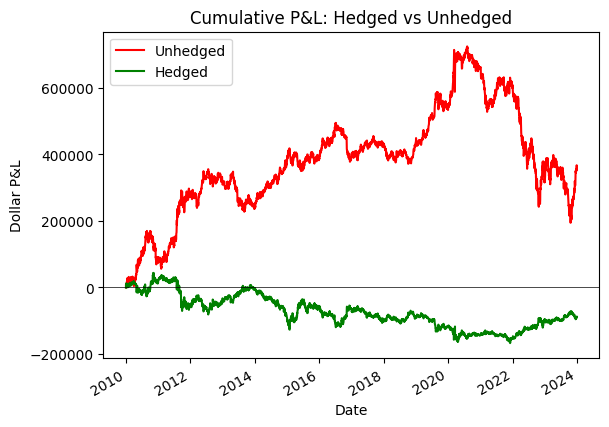

In [22]:

import matplotlib.pyplot as plt

unhedged_pnl.cumsum().plot(label='Unhedged', color='red')
hedged_pnl.cumsum().plot(label='Hedged', color='green')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Cumulative P&L: Hedged vs Unhedged')
plt.ylabel('Dollar P&L')
plt.legend()
plt.show()